# CONUS TXx Extremes: Figure Guide

This notebook compares spatial extreme-temperature estimates from extRemes for the contiguous United States (CONUS) and Alaska over 1979-2025. The analysis maps the 100-year return level and the fitted location, scale, and shape parameters for the beginning and end years of the record.

The extRemes simulations used a nonstationary GEV framework, with a smoothed GLOST (LOESS) temperature anomaly series included as a time covariate in the location and scale parameters.

The figures are organized as follows:

- A GLOST LOESS time series provides the climate context for the analysis period.
- Return-level maps show the estimated 100-year extreme temperature for 1979, 2025, and the change between those years.
- Parameter maps show how the fitted location, scale, and shape parameters vary spatially and change over time.

All map values use degrees Fahrenheit where applicable. Alaska and CONUS are plotted side by side using the same geographic coordinate system and state-border overlay.

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import scipy
import cftime
import cartopy
import cartopy.crs as ccrs
import cmaps
from xhistogram.xarray import histogram
from statsmodels.nonparametric.smoothers_lowess import lowess as  sm_lowess
from copy import copy
import geopandas as gpd
from shapely.geometry import Point

In [2]:
from matplotlib import cm
import cmaps
import matplotlib as mpl
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors

In [3]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

In [4]:
import warnings
warnings.filterwarnings('ignore')

# READ extRemes ERA5 output FILES

### Input data and fitted fields

The extRemes NetCDF files provide gridded estimates for CONUS and Alaska. The notebook loads the 100-year return level together with the location, scale, and shape fields, then selects 1979 and 2025 for comparison.

In [5]:
yearb=1979
yeare=2025
lon_min = 235
lon_max = 293
lat_min = 25
lat_max = 50

dirin ='~/data/TXx'

ds1 = xr.open_dataset(f'{dirin}/TXx_CONUS_ij_glost_extremes_1979_2025.nc')
rl1001 = ds1['rl100']
loc1 = ds1['location'] 
scale1 = ds1['scale'] 
shape1 = ds1['shape'] 
pvalue1 = ds1['pvalue'] 

ds3 = xr.open_dataset(f'{dirin}/TXx_Alaska_ij_glost_extremes_1979_2025.nc')
rl1003 = ds3['rl100']
loc3 = ds3['location'] 
scale3 = ds3['scale'] 
shape3 = ds3['shape'] 
pvalue3 = ds3['pvalue'] 

units = '°F'

Tlabels = ['extRemes 1979-2025 (time covariate for location and scale)']

In [6]:
Trl100 = [rl1003,rl1001]
Tloc = [loc3,loc1]
Tscale = [scale3,scale1]
Tshape = [shape3,shape1]
#


In [7]:
fileGLOST = '~/data/AFI/annual_LOESS_NOAA_GLOST_anomaly.nc'
ds_glost=xr.open_dataset(fileGLOST)

ann_glost = ds_glost['glost']

Text(0.5, 1.0, 'GLOST LOESS')

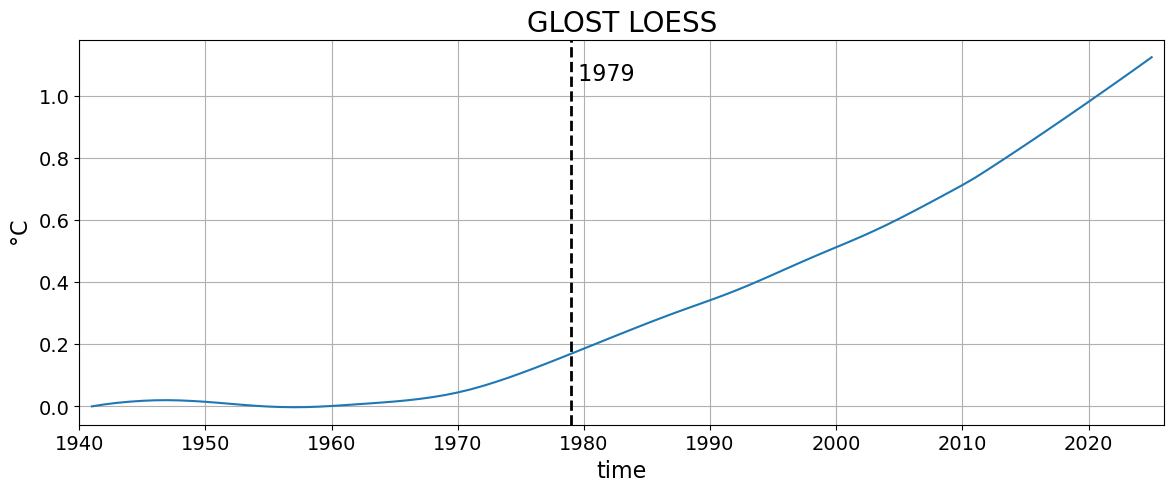

In [8]:
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(14,5))
ann_glost.plot(ax=ax)
ax.axvline(1979,c='k',lw=2.,ls='--')
ax.text(1979,1.05,' 1979',fontsize=16)
ax.grid()
ax.set_xlim([1940,2026])
ax.tick_params(axis='both', labelsize=14)
ax.set_xlabel('time',fontsize=16)
ax.set_ylabel('$\degree$C',fontsize=16)
plt.title('GLOST LOESS',fontsize=20)

**Figure caption.** Annual global surface temperature anomalies from NOAA, GLOST after applying a LOWESS (locally weighted scatterplot smoothing) filter to the monthly anomaly record. The smoothing was performed using a 30-year window (fraction = 30 × 12 / N) with five robustness iterations, and the resulting smoothed monthly series was converted to annual means. The dashed vertical line marks 1979, the beginning of the satellite era and the period used in subsequent analyses. Temperature anomalies are expressed in degrees Celsius (°C) relative to the NOAA GLOST reference climatology (1971–2000).

# PLOT Return Level 100

### Return-level maps

The next three figures use a common color scale to compare the estimated 100-year return level at the start and end of the analysis period, followed by the end-minus-start difference. Alaska and CONUS share the same scale so spatial patterns can be compared directly.

Text(0.5, 0.98, 'extRemes 1979-2025 (time covariate for location and scale) \n\n Return Level 100year: 1979')

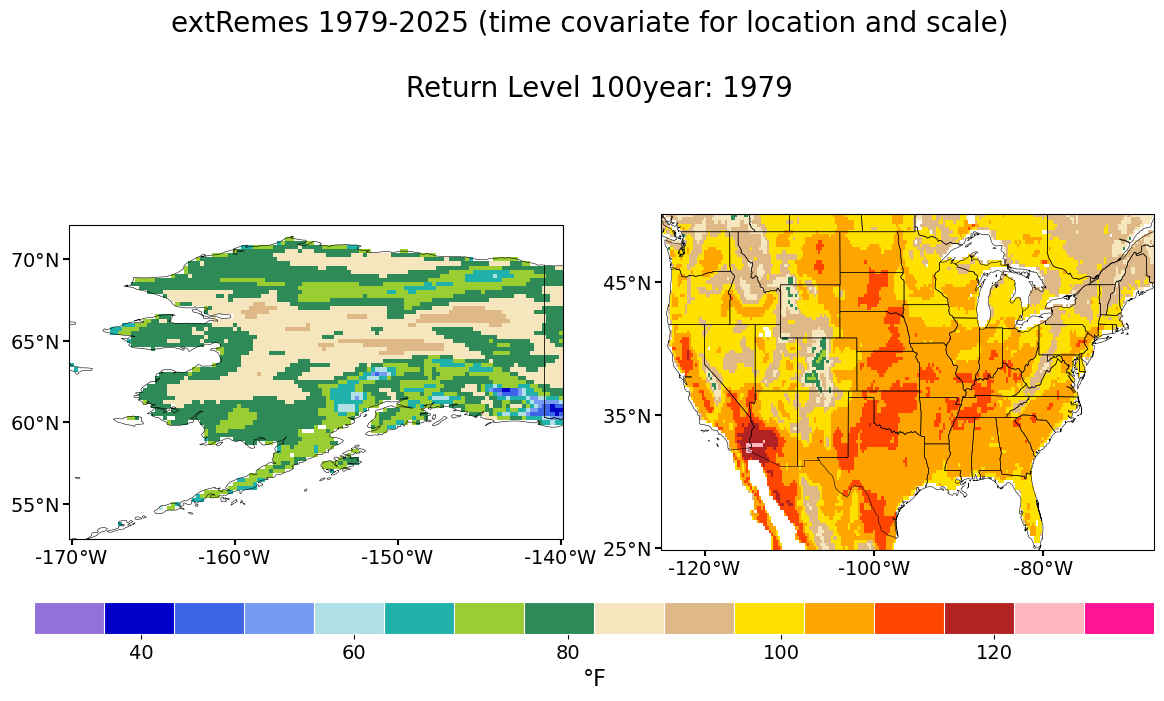

In [9]:
clevs = np.arange(30,140,5)
cmap = plt.get_cmap(cmaps.amwg,len(clevs)).copy()

proj=ccrs.PlateCarree()
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.15, right=0.9)
ax = ax.flatten()
for ix in range(0,len(Tloc)):
  cc = Trl100[ix].sel(time=yearb).plot.pcolormesh(ax=ax[ix],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],add_colorbar=False)
  ####
for ix in range(0,len(Tloc)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_title(f'',fontsize=18)  
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
asp = np.diff(ax[0].get_xlim())[0] / np.diff(ax[0].get_ylim())[0]
ax[1].set_aspect(asp)
#
ax_cbar = fig.add_axes([0.1, 0.2, 0.8, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',drawedges=True)
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'{units}',fontsize=16)  
cbar.outline.set_edgecolor('w')
cbar.dividers.set_edgecolor('w')
cbar.dividers.set_linewidth(0.8)
#
#
plt.suptitle(f'{Tlabels[0]} \n\n Return Level 100year: {yearb}',fontsize=20)  

**Figure caption.** Estimated 100-year return level for 1979, shown for Alaska and CONUS. Colors indicate the modeled extreme temperature in degrees Fahrenheit.

Text(0.5, 0.98, 'extRemes 1979-2025 (time covariate for location and scale) \n\n Return Level 100year: 2025')

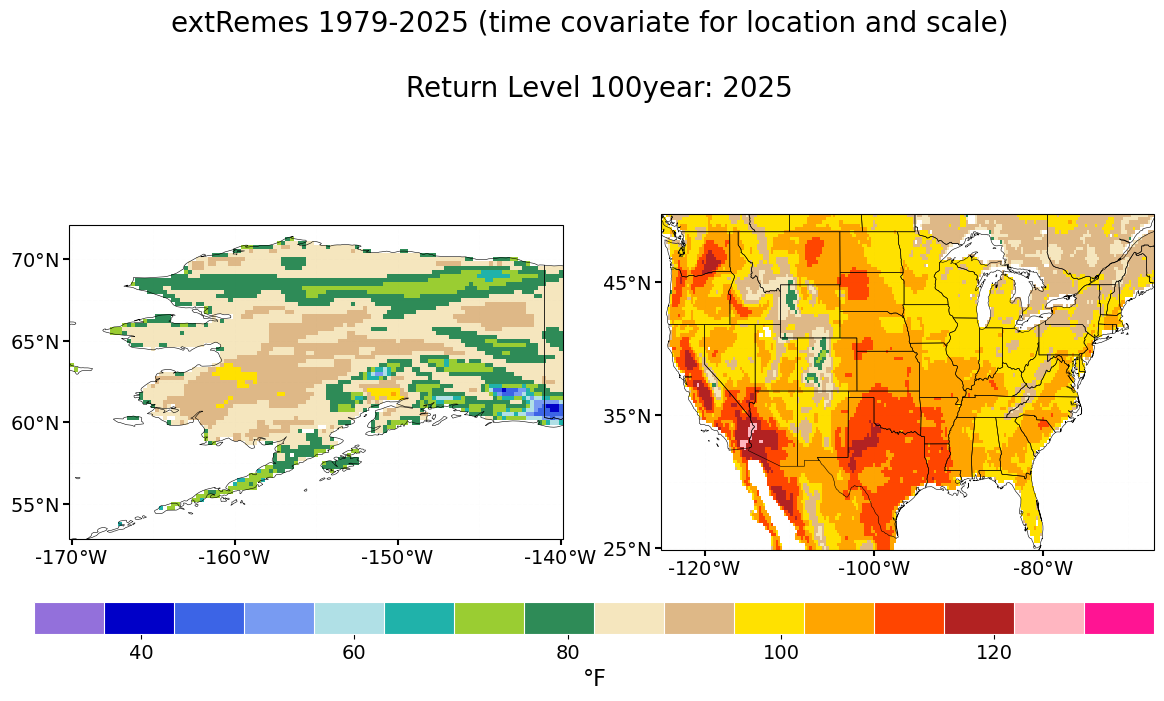

In [10]:


clevs = np.arange(30,140,5)
cmap = plt.get_cmap(cmaps.amwg,len(clevs)).copy()

proj=ccrs.PlateCarree()
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.15, right=0.9)
ax = ax.flatten()
for ix in range(0,len(Tloc)):
  cc = Trl100[ix].sel(time=yeare).plot.pcolormesh(ax=ax[ix],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],add_colorbar=False)
  ####
for ix in range(0,len(Tloc)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_title(f'',fontsize=18)  
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
asp = np.diff(ax[0].get_xlim())[0] / np.diff(ax[0].get_ylim())[0]
ax[1].set_aspect(asp)
#
ax_cbar = fig.add_axes([0.1, 0.2, 0.8, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',drawedges=True)
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'{units}',fontsize=16)  
cbar.outline.set_edgecolor('w')
cbar.dividers.set_edgecolor('w')
cbar.dividers.set_linewidth(0.8)
#
#
plt.suptitle(f'{Tlabels[0]} \n\n Return Level 100year: {yeare}',fontsize=20)  

**Figure caption.** Estimated 100-year return level for 2025, using the same map layout and temperature scale as the 1979 figure.

Text(0.5, 0.98, 'extRemes 1979-2025 (time covariate for location and scale) \n\n Return Level 100year, Difference 2025 - 1979')

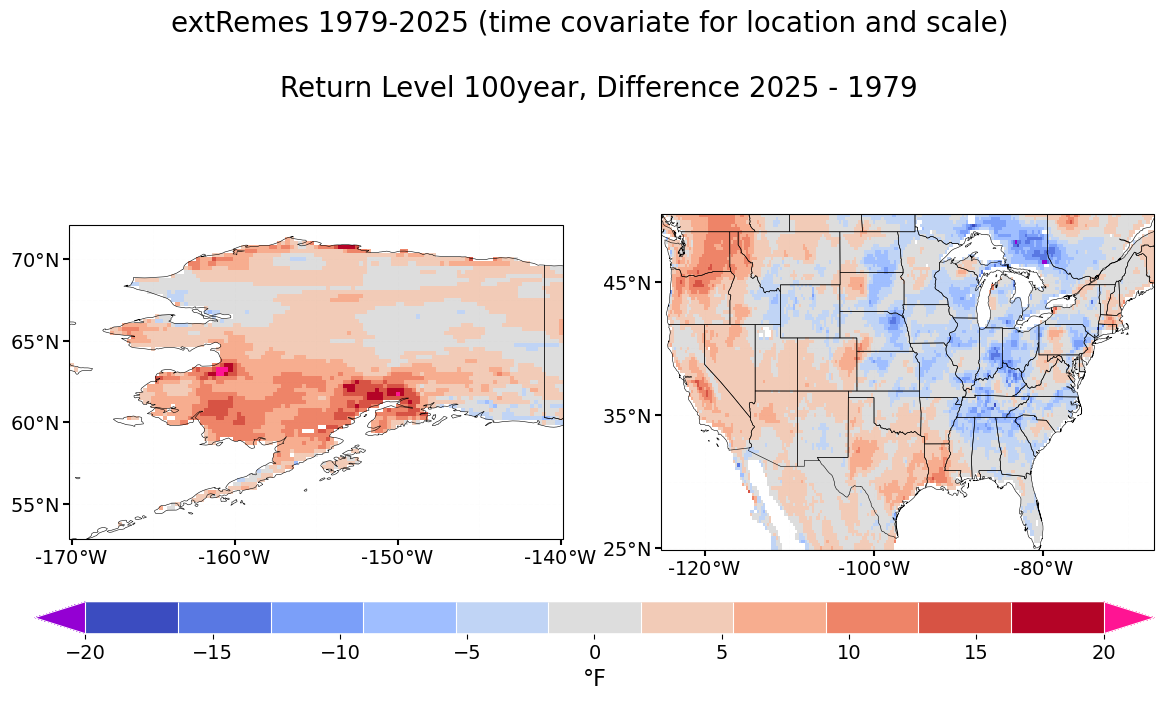

In [11]:
clevs = np.arange(-20,24,4)
cmap = plt.get_cmap('coolwarm',len(clevs)).copy()

cmap.set_under('darkviolet')
cmap.set_over('deeppink')
norm = mcolors.TwoSlopeNorm(vcenter=0,vmin=clevs[0],vmax=-clevs[0])
proj=ccrs.PlateCarree()

fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.15, right=0.9)
ax = ax.flatten()
for ix in range(0,len(Tloc)):
  cc = (Trl100[ix].sel(time=yeare)-Trl100[ix].sel(time=yearb)).plot.pcolormesh(ax=ax[ix],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],add_colorbar=False)
  ####
for ix in range(0,len(Tloc)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_title(f'',fontsize=18)  
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
asp = np.diff(ax[0].get_xlim())[0] / np.diff(ax[0].get_ylim())[0]
ax[1].set_aspect(asp)
#
ax_cbar = fig.add_axes([0.1, 0.2, 0.8, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',drawedges=True,extend='both',norm=norm)
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'{units}',fontsize=16)  
cbar.outline.set_edgecolor('w')
cbar.dividers.set_edgecolor('w')
cbar.dividers.set_linewidth(0.8)
#
#
plt.suptitle(f'{Tlabels[0]} \n\n Return Level 100year, Difference {yeare} - {yearb}',fontsize=20)  

**Figure caption.** Change in the estimated 100-year return level from 1979 to 2025, calculated as 2025 minus 1979. Warm colors indicate increases and cool colors indicate decreases.

### Location parameter maps

The location parameter represents the central level of the fitted extreme-value distribution. These maps show its spatial pattern in 1979, its pattern in 2025, and the change between the two years.

Text(0.5, 0.98, 'extRemes 1979-2025 (time covariate for location and scale) \n\n Location parameter: 1979')

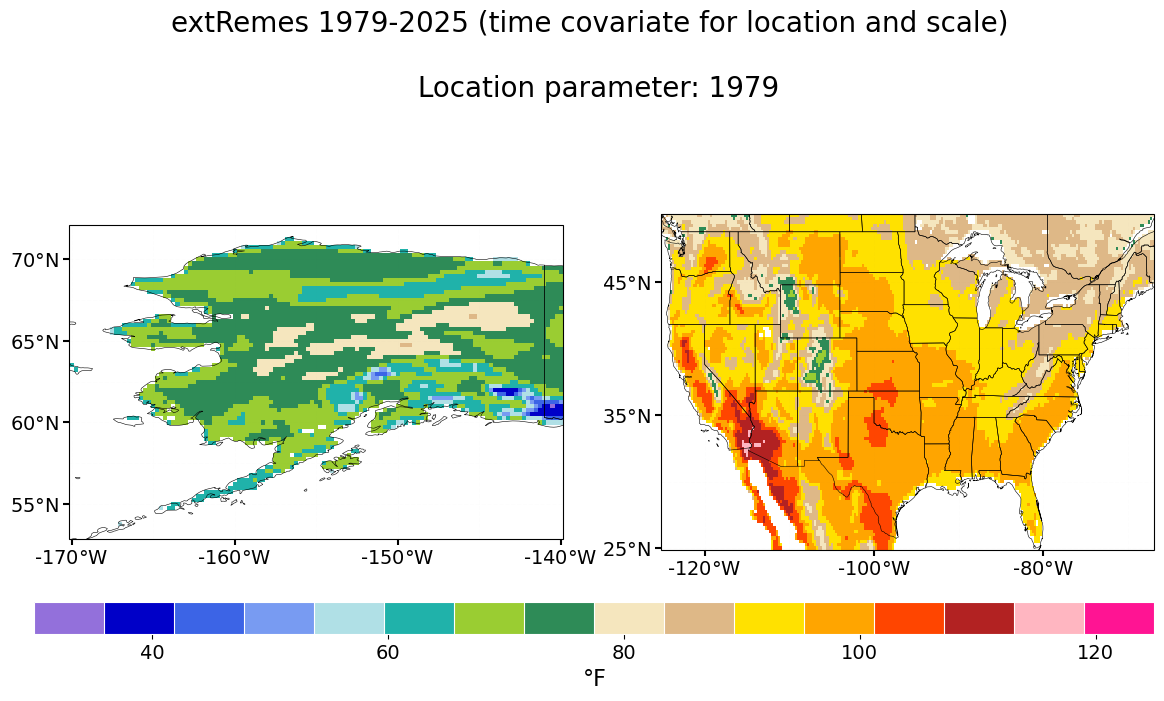

In [19]:
clevs = np.arange(30,130,5)
cmap = plt.get_cmap(cmaps.amwg,len(clevs)).copy()

proj=ccrs.PlateCarree()

fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.15, right=0.9)
ax = ax.flatten()
for ix in range(0,len(Tloc)):
  cc = Tloc[ix].sel(time=yearb).plot.pcolormesh(ax=ax[ix],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],add_colorbar=False)
  ####
for ix in range(0,len(Tloc)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_title(f'',fontsize=18)  
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
asp = np.diff(ax[0].get_xlim())[0] / np.diff(ax[0].get_ylim())[0]
ax[1].set_aspect(asp)
#
ax_cbar = fig.add_axes([0.1, 0.2, 0.8, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',drawedges=True)
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'{units}',fontsize=16)  
cbar.outline.set_edgecolor('w')
cbar.dividers.set_edgecolor('w')
cbar.dividers.set_linewidth(0.8)
#
plt.suptitle(f'{Tlabels[0]} \n\n Location parameter: {yearb}',fontsize=20)  

**Figure caption.** Location parameter field for 1979, representing the fitted central level of the extreme-value distribution.

Text(0.5, 0.98, 'extRemes 1979-2025 (time covariate for location and scale) \n\n Location parameter: 2025')

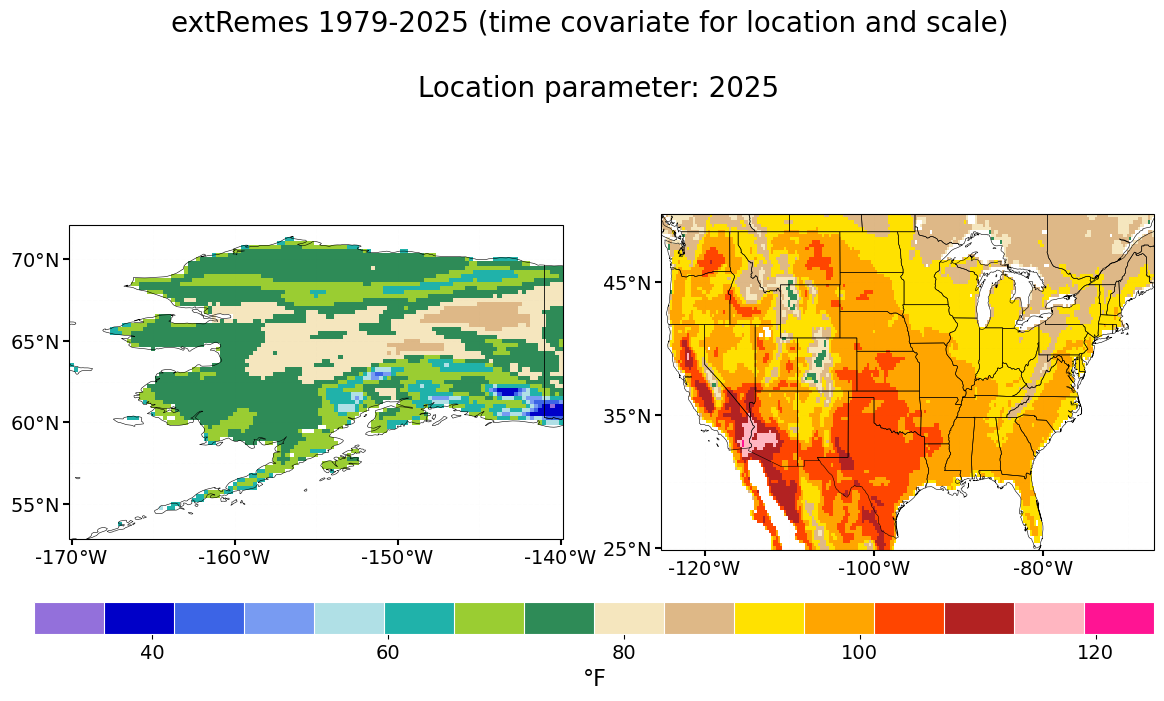

In [13]:
clevs = np.arange(30,130,5)
cmap = plt.get_cmap(cmaps.amwg,len(clevs)).copy()

proj=ccrs.PlateCarree()

fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.15, right=0.9)
ax = ax.flatten()
for ix in range(0,len(Tloc)):
  cc = Tloc[ix].sel(time=yeare).plot.pcolormesh(ax=ax[ix],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],add_colorbar=False)
  ####
for ix in range(0,len(Tloc)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_title(f'',fontsize=18)  
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
asp = np.diff(ax[0].get_xlim())[0] / np.diff(ax[0].get_ylim())[0]
ax[1].set_aspect(asp)
#
ax_cbar = fig.add_axes([0.1, 0.2, 0.8, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',drawedges=True)
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'{units}',fontsize=16)  
cbar.outline.set_edgecolor('w')
cbar.dividers.set_edgecolor('w')
cbar.dividers.set_linewidth(0.8)
#
plt.suptitle(f'{Tlabels[0]} \n\n Location parameter: {yeare}',fontsize=20)  

**Figure caption.** Location parameter field for 2025, using the same scale and geographic layout as the 1979 map.

Text(0.5, 0.98, 'extRemes 1979-2025 (time covariate for location and scale) \n\n Location, Difference 2025 - 1979')

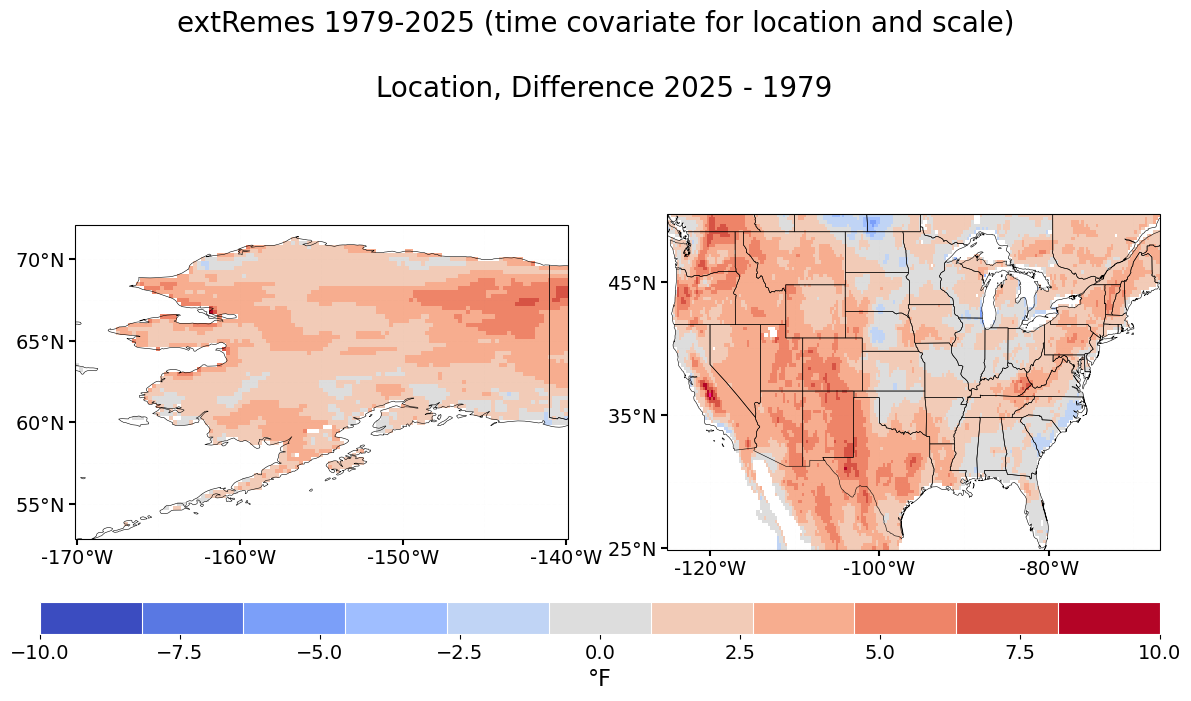

In [14]:
clevs = np.arange(-10,12,2)
cmap = plt.get_cmap('coolwarm',len(clevs)).copy()

cmap.set_under('darkviolet')
cmap.set_over('deeppink')
norm = mcolors.TwoSlopeNorm(vcenter=0,vmin=clevs[0],vmax=-clevs[0])
proj=ccrs.PlateCarree()

fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.15, right=0.9)
ax = ax.flatten()
for ix in range(0,len(Tloc)):
  cc = (Tloc[ix].sel(time=yeare)-Tloc[ix].sel(time=yearb)).plot.pcolormesh(ax=ax[ix],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],add_colorbar=False)
  ####
for ix in range(0,len(Tloc)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_title(f'',fontsize=18)  
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
asp = np.diff(ax[0].get_xlim())[0] / np.diff(ax[0].get_ylim())[0]
ax[1].set_aspect(asp)
#
ax_cbar = fig.add_axes([0.1, 0.2, 0.8, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',drawedges=True,norm=norm)
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'{units}',fontsize=16)  
cbar.outline.set_edgecolor('w')
cbar.dividers.set_edgecolor('w')
cbar.dividers.set_linewidth(0.8)
#
#
plt.suptitle(f'{Tlabels[0]} \n\n Location, Difference {yeare} - {yearb}',fontsize=20)  

**Figure caption.** Change in the location parameter from 1979 to 2025, calculated as 2025 minus 1979.

### Scale parameter maps

The scale parameter describes the spread of the fitted extreme-value distribution. The following maps compare its spatial structure in 1979 and 2025 and show the modeled change over the interval.

Text(0.5, 0.98, 'extRemes 1979-2025 (time covariate for location and scale) \n\n Scale parameter: 1979')

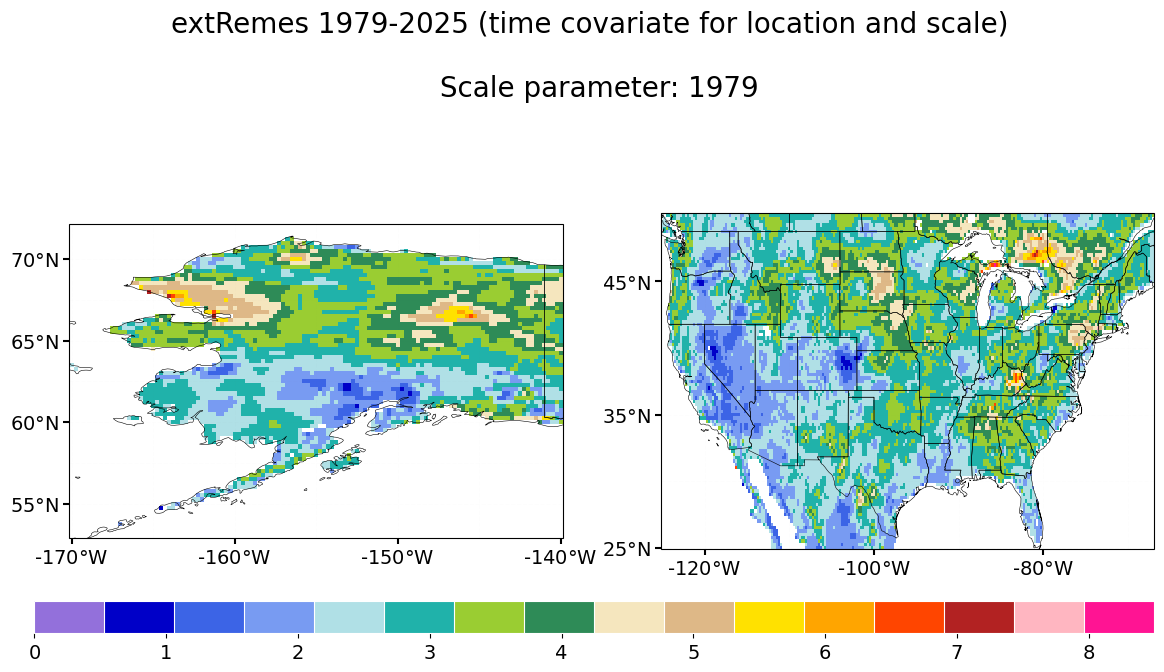

In [15]:
clevs = np.arange(0,9,.5)
cmap = plt.get_cmap(cmaps.amwg,len(clevs)).copy()

proj=ccrs.PlateCarree()

fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.15, right=0.9)
ax = ax.flatten()
for ix in range(0,len(Tloc)):
  cc = Tscale[ix].sel(time=yearb).plot.pcolormesh(ax=ax[ix],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],add_colorbar=False)
  ####
for ix in range(0,len(Tloc)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_title(f'',fontsize=18)  
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
asp = np.diff(ax[0].get_xlim())[0] / np.diff(ax[0].get_ylim())[0]
ax[1].set_aspect(asp)
#
ax_cbar = fig.add_axes([0.1, 0.2, 0.8, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',drawedges=True)
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)  
cbar.outline.set_edgecolor('w')
cbar.dividers.set_edgecolor('w')
cbar.dividers.set_linewidth(0.8)
#
plt.suptitle(f'{Tlabels[0]} \n\n Scale parameter: {yearb}',fontsize=20)  

**Figure caption.** Scale parameter field for 1979, showing the modeled spatial spread of the extreme-value distribution.

Text(0.5, 0.98, 'extRemes 1979-2025 (time covariate for location and scale) \n\n Scale parameter: 2025')

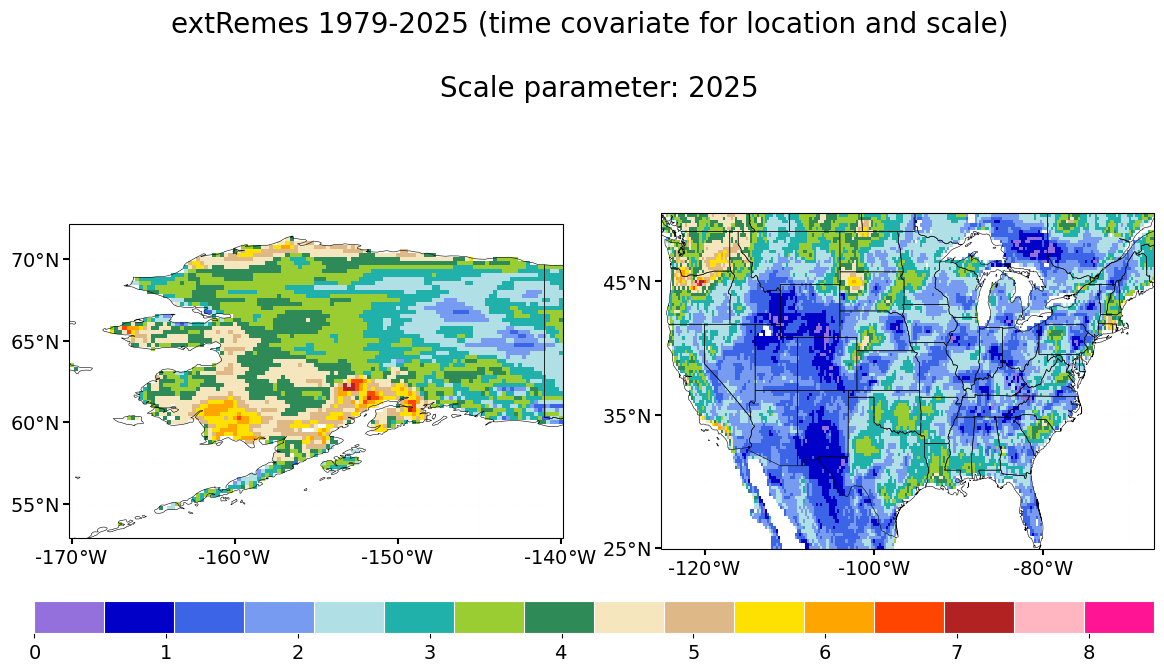

In [16]:
clevs = np.arange(0,9,.5)
cmap = plt.get_cmap(cmaps.amwg,len(clevs)).copy()

proj=ccrs.PlateCarree()

fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.15, right=0.9)
ax = ax.flatten()
for ix in range(0,len(Tloc)):
  cc = Tscale[ix].sel(time=yeare).plot.pcolormesh(ax=ax[ix],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],add_colorbar=False)
  ####
for ix in range(0,len(Tloc)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_title(f'',fontsize=18)  
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
asp = np.diff(ax[0].get_xlim())[0] / np.diff(ax[0].get_ylim())[0]
ax[1].set_aspect(asp)
#
ax_cbar = fig.add_axes([0.1, 0.2, 0.8, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',drawedges=True)
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)  
cbar.outline.set_edgecolor('w')
cbar.dividers.set_edgecolor('w')
cbar.dividers.set_linewidth(0.8)
#
plt.suptitle(f'{Tlabels[0]} \n\n Scale parameter: {yeare}',fontsize=20)  

**Figure caption.** Scale parameter field for 2025, plotted with the same map layout as the 1979 scale field.

Text(0.5, 0.98, 'extRemes 1979-2025 (time covariate for location and scale) \n\n Scale parameter, Difference 2025 - 1979')

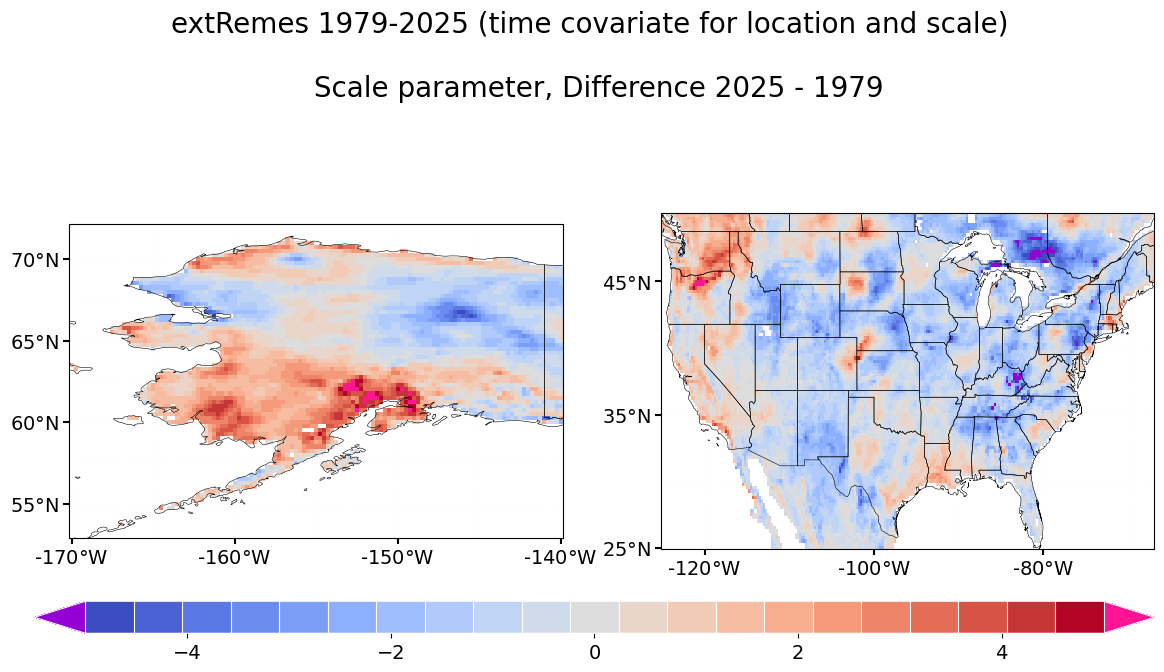

In [17]:
clevs = np.arange(-5.,5.5,0.5)
cmap = plt.get_cmap('coolwarm',len(clevs)).copy()
cmap.set_under('darkviolet')
cmap.set_over('deeppink')
norm = mcolors.TwoSlopeNorm(vcenter=0,vmin=clevs[0],vmax=-clevs[0])

proj=ccrs.PlateCarree()

fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.15, right=0.9)
ax = ax.flatten()
for ix in range(0,len(Tloc)):
  cc = (Tscale[ix].sel(time=yeare)-Tscale[ix].sel(time=yearb)).plot.pcolormesh(ax=ax[ix],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],add_colorbar=False)
  ####
for ix in range(0,len(Tloc)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_title(f'',fontsize=18)  
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
asp = np.diff(ax[0].get_xlim())[0] / np.diff(ax[0].get_ylim())[0]
ax[1].set_aspect(asp)
#
ax_cbar = fig.add_axes([0.1, 0.2, 0.8, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',drawedges=True,extend='both',norm=norm)
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)  
cbar.outline.set_edgecolor('w')
cbar.dividers.set_edgecolor('w')
cbar.dividers.set_linewidth(0.8)
#
#
plt.suptitle(f'{Tlabels[0]} \n\n Scale parameter, Difference {yeare} - {yearb}',fontsize=20)  

**Figure caption.** Change in the scale parameter from 1979 to 2025, calculated as 2025 minus 1979.

### Shape parameter 

The shape parameter controls the tail behavior of the fitted extreme-value distribution. Its diverging color scale emphasizes the sign and magnitude of the fitted value. 

Text(0.5, 0.98, 'extRemes 1979-2025 (time covariate for location and scale) \n\n Shape parameter')

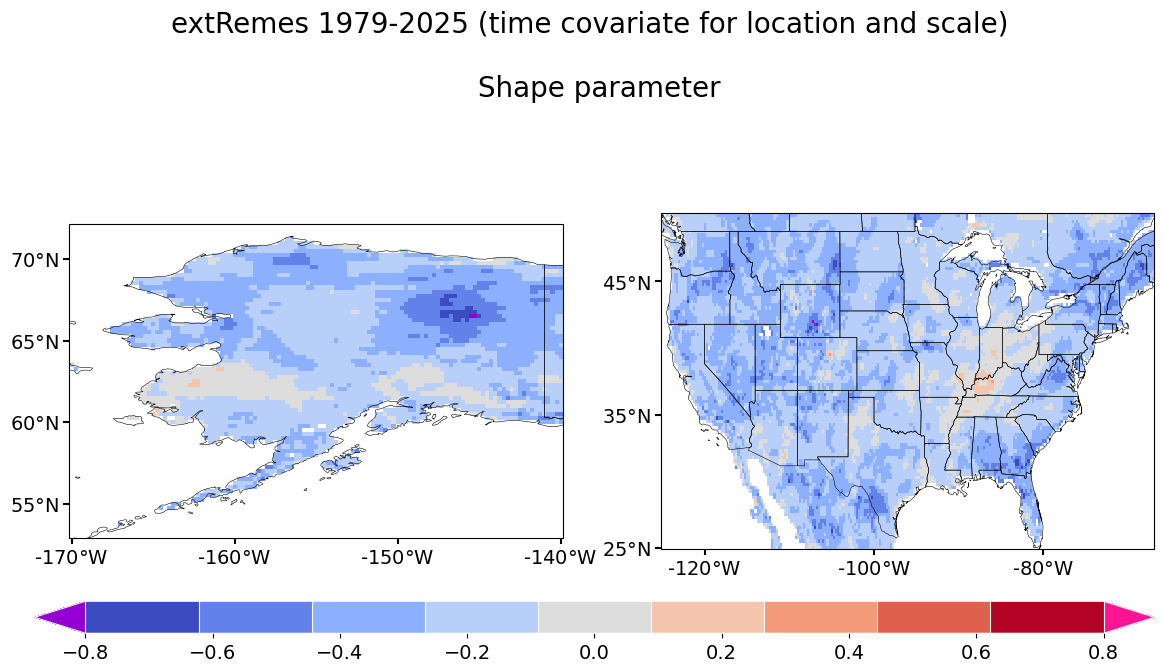

In [18]:
clevs = np.arange(-0.8,1,0.2)

cmap = cm.get_cmap('coolwarm',len(clevs))
cmap.set_under('darkviolet')
cmap.set_over('deeppink')
norm = mcolors.TwoSlopeNorm(vcenter=0,vmin=clevs[0],vmax=-clevs[0])
proj=ccrs.PlateCarree()

fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.15, right=0.9)
ax = ax.flatten()
for ix in range(0,len(Tloc)):
  cc = Tshape[ix].sel(time=yeare).plot.pcolormesh(ax=ax[ix],cmap=cmap,vmin=clevs[0],vmax=clevs[-1],add_colorbar=False)
  ####
for ix in range(0,len(Tloc)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_title(f'',fontsize=18)  
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
asp = np.diff(ax[0].get_xlim())[0] / np.diff(ax[0].get_ylim())[0]
ax[1].set_aspect(asp)
#
ax_cbar = fig.add_axes([0.1, 0.2, 0.8, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',drawedges=True,extend='both')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)  
cbar.outline.set_edgecolor('w')
cbar.dividers.set_edgecolor('w')
cbar.dividers.set_linewidth(0.8)
#
plt.suptitle(f'{Tlabels[0]} \n\n Shape parameter',fontsize=20)  

**Figure caption.** Fitted shape parameter. The diverging palette highlights negative and positive tail-shape values, while the extended colors mark values outside the displayed range.